<a href="https://colab.research.google.com/github/eliza-aurora-carling/Admin/blob/main/Diss_code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 
CIRCADIAN-DOPAMINE MODEL FOR PARKINSON'S DISEASE
Based on Kim & Reed (2021) with human diurnal adaptation
🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 🕐 
HEALTHY VALIDATION: Simulating 5 days (120 hours)

Steady-state dopamine metrics (last 24 hours):
  Peak dopamine: 0.139 nM
  Trough dopamine: 0.130 nM
  Amplitude: 0.009 nM
  Peak time: 7.4 hours (expected: daytime)


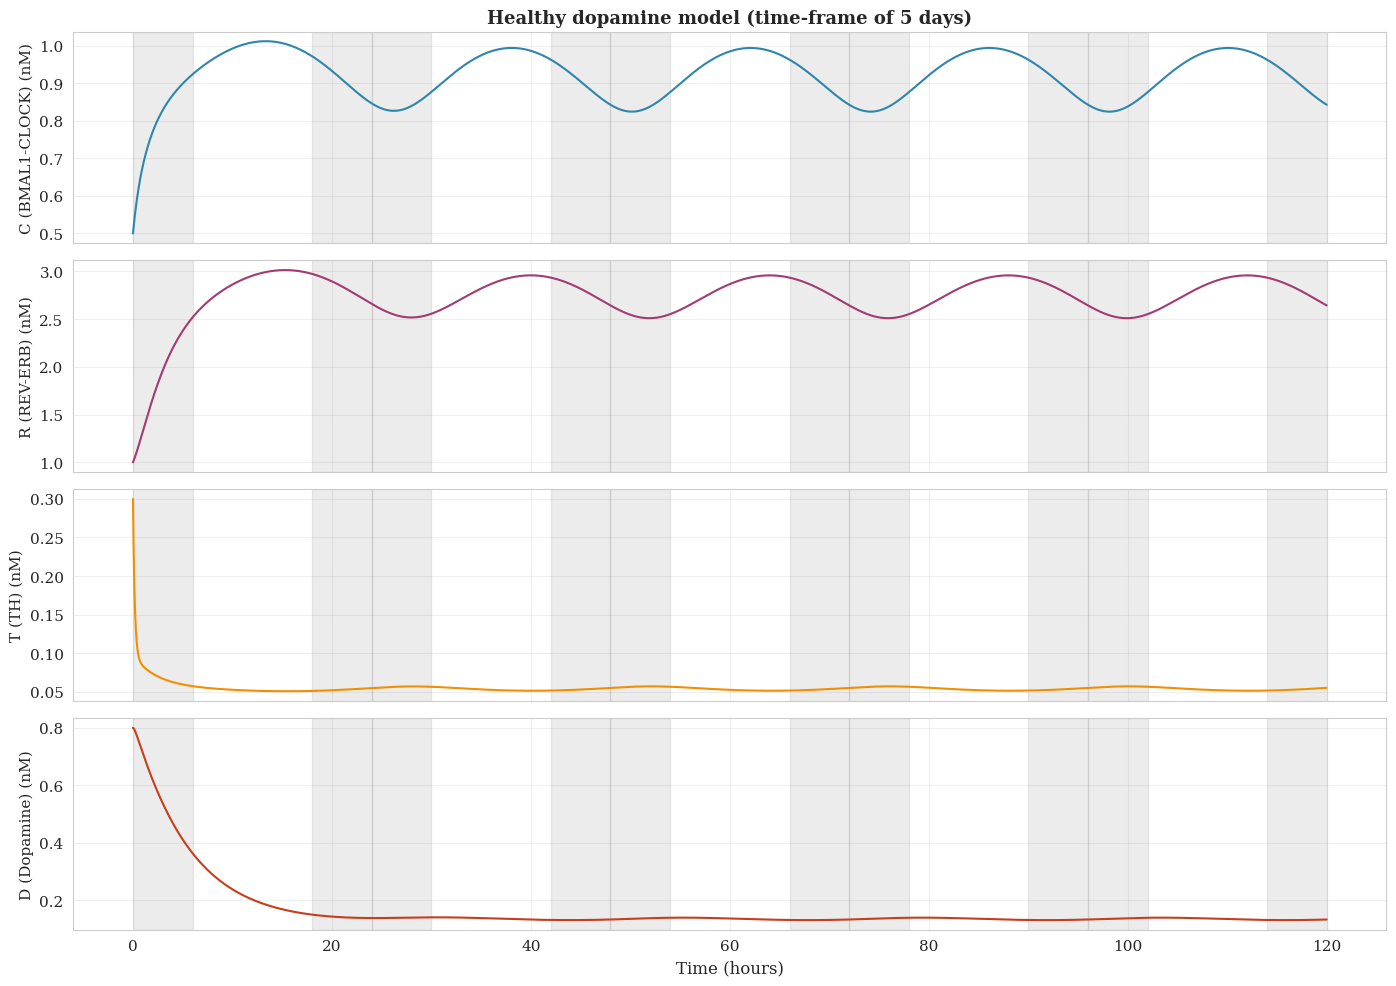


PD PROGRESSION: Healthy vs. moderate vs. advanced

Healthy (N=1.0):
  Peak dopamine: 0.139 nM
  Mean dopamine: 0.134 nM
  Reduction vs healthy: 0.0%

Moderate PD (N=0.5):
  Peak dopamine: 0.070 nM
  Mean dopamine: 0.068 nM
  Reduction vs healthy: 49.4%

Advanced PD (N=0.2):
  Peak dopamine: 0.028 nM
  Mean dopamine: 0.027 nM
  Reduction vs healthy: 79.6%


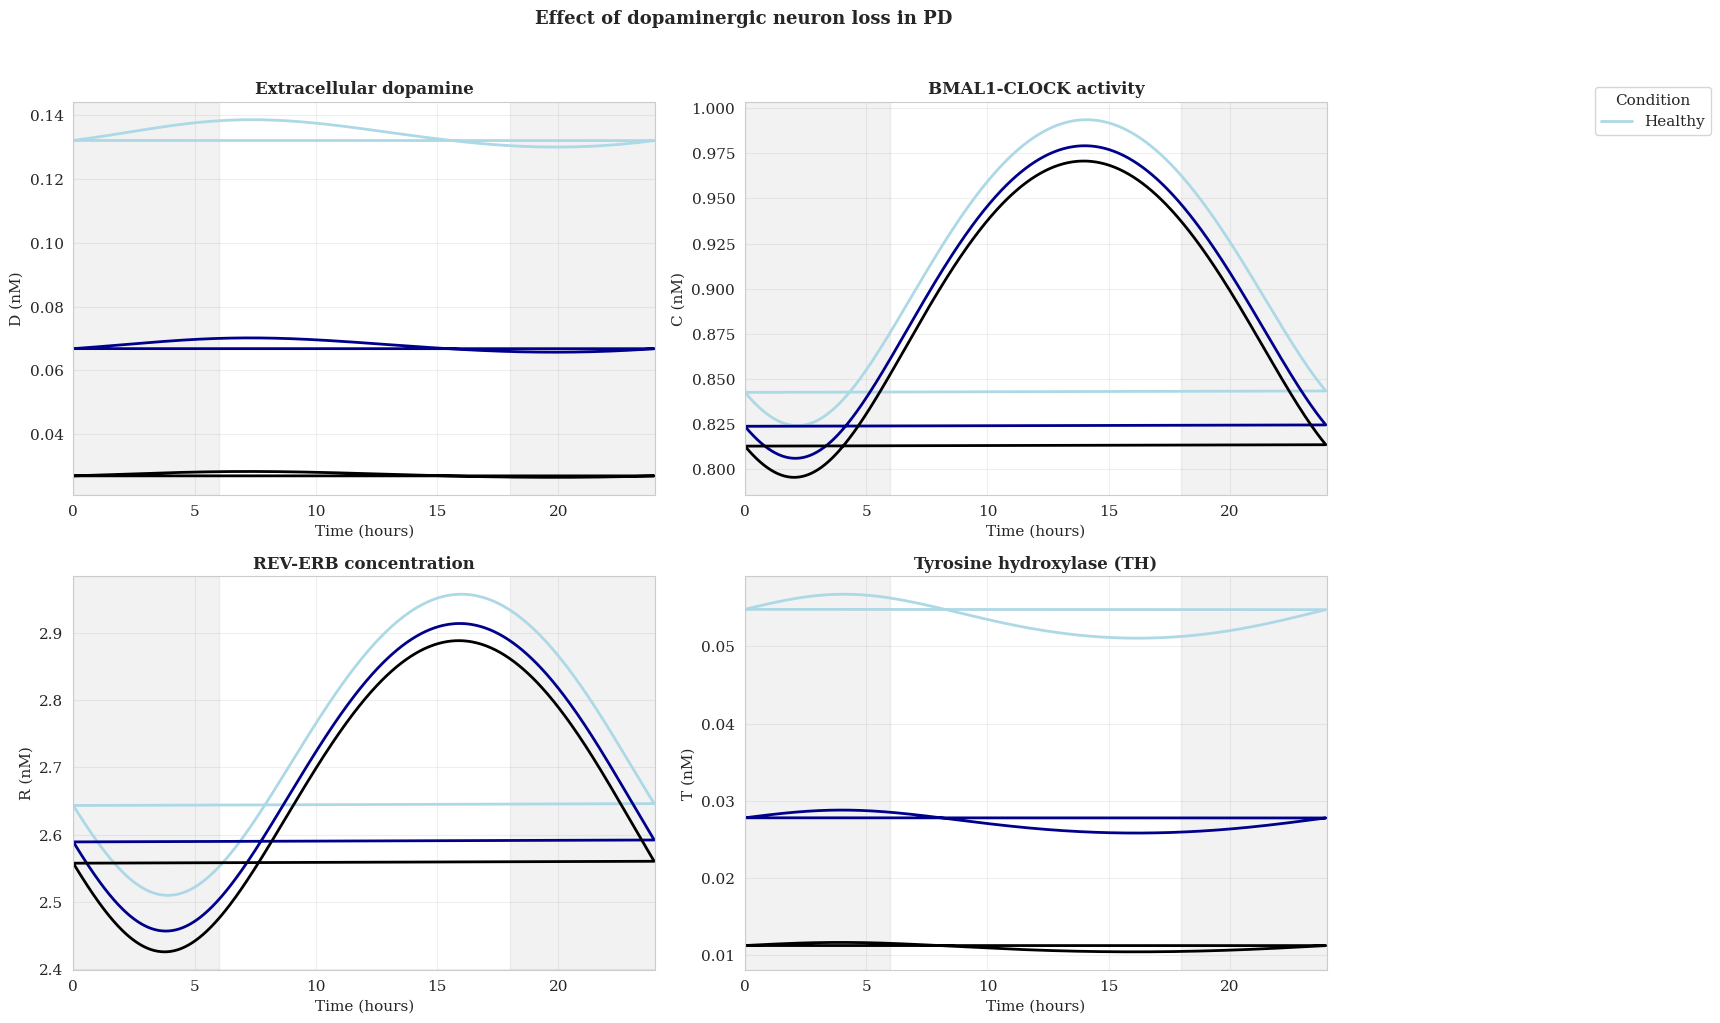


FEEDBACK SENSITIVITY: Varying β_DC

β_DC = 0.0:
  Clock period: nan hours
  Dopamine amplitude: 0.009 nM

β_DC = 0.05:
  Clock period: nan hours
  Dopamine amplitude: 0.009 nM

β_DC = 0.1:
  Clock period: nan hours
  Dopamine amplitude: 0.009 nM

β_DC = 0.15:
  Clock period: nan hours
  Dopamine amplitude: 0.008 nM

β_DC = 0.2:
  Clock period: nan hours
  Dopamine amplitude: 0.008 nM


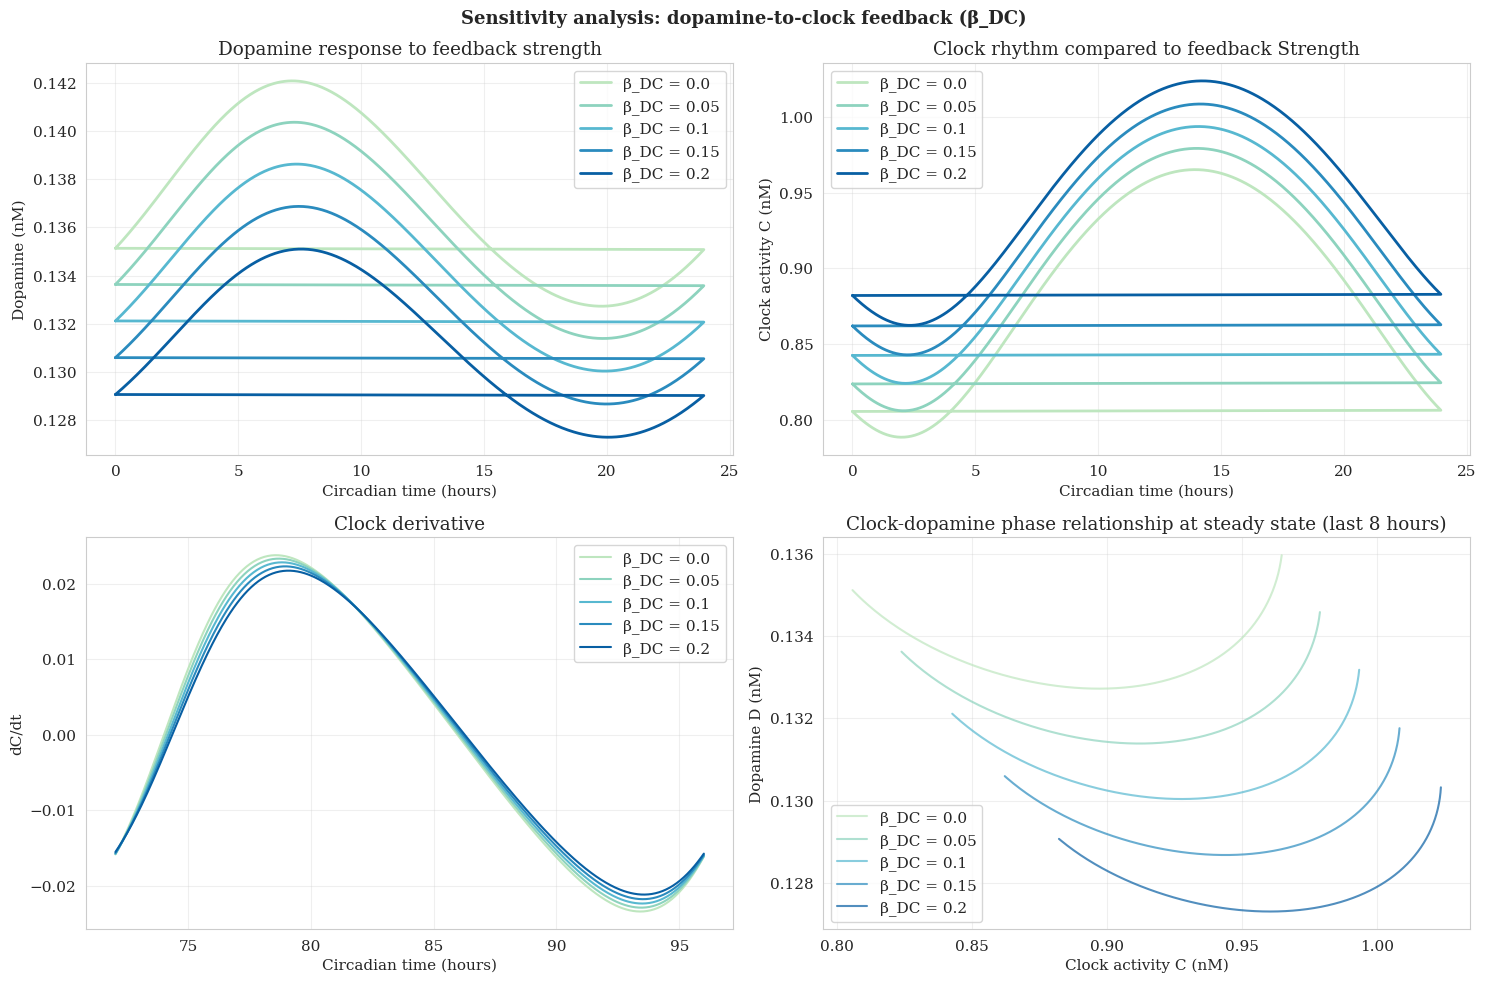


TH REPRESSION TEST: Verifying REV-ERB → TH coupling

Correlation between REV-ERB and TH:
  With repression: r = -0.999 (negative correlation expected)
  Without repression: r = -0.162


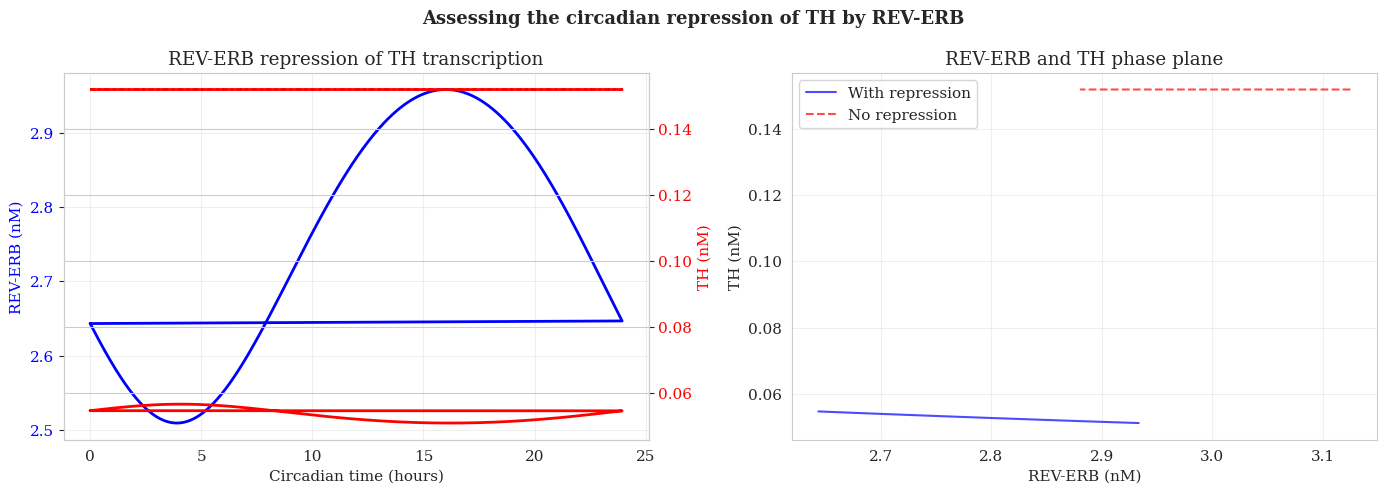


SUMMARY STATISTICS TABLE

-------------------------------------------------------------------------------------
Condition       N     Mean D     Peak D     D Amp      Mean TH   
-------------------------------------------------------------------------------------
Healthy         1.0   0.134      0.139      0.009      0.054     
Moderate PD     0.5   0.068      0.070      0.004      0.027     
Advanced PD     0.2   0.027      0.028      0.002      0.011     
-------------------------------------------------------------------------------------

ANALYSIS COMPLETE
Figures saved: healthy_validation.png, pd_progression.png,
               feedback_sensitivity.png, th_repression_test.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import pearsonr
import traceback
import sys # Import sys module

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Set font for titles to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


class CircadianDopamineModel:
    """
    Four-ODE model coupling circadian clock dynamics with dopamine synthesis.

    State variables:
        C: BMAL1-CLOCK activity (nM)
        R: REV-ERB concentration (nM)
        T: Tyrosine hydroxylase (TH) concentration (nM)
        D: Extracellular dopamine concentration (nM)

    Parameters are based on Kim & Reed (2021) and Best et al. (2009),
    with adjustments for human diurnal rhythms.
    """

    def __init__(self):
        # Clock parameters (chosen for stable 24h oscillations)
        self.alpha_C = 1.0       # Max clock production rate (nM/hr)
        self.k_C = 0.5           # Clock half-max repression (nM)
        self.n = 4.0             # Clock Hill coefficient
        self.gamma_C = 0.1       # Clock degradation rate (1/hr)

        # Dopamine feedback to clock
        self.beta_DC = 0.1       # Dopamine feedback strength (1/(hr·nM))

        # REV-ERB parameters (Kim & Reed, 2021)
        self.beta_R = 1.5        # REV-ERB production rate (1/hr)
        self.gamma_R = 0.5       # REV-ERB degradation rate (1/hr)

        # TH parameters (Kim & Reed, 2021)
        self.beta_T = 0.85       # Max TH synthesis rate (nM/hr)
        self.k_T = 1.5           # REV-ERB half-max repression (nM)
        self.m = 1.0             # TH Hill coefficient
        self.gamma_T = 5.6       # TH degradation rate (1/hr, half-life ~7.4 min)

        # Dopamine parameters (estimated from Best et al., 2009)
        self.sigma = 0.5         # Dopamine synthesis rate per TH (1/hr)
        self.delta = 0.2         # Dopamine clearance rate (1/hr)

        # Disease parameter
        self.N = 1.0             # Fraction of healthy dopaminergic neurons (1.0 = healthy)

    def light_input(self, t):
        """
        Sinusoidal light input function for human diurnal rhythm.

        Peak at t = 12 hours (midday), trough at t = 0, 24 hours (midnight).
        Oscillates between 0.5 and 1.5 with mean 1.0.

        Args:
            t: Time in hours

        Returns:
            Light input value at time t
        """
        return 1.0 + 0.5 * np.sin((np.pi / 12) * t - np.pi / 2)

    def system(self, t, y):
        """
        Right-hand side of the ODE system.

        Args:
            t: Current time (hours)
            y: State vector [C, R, T, D]

        Returns:
            Derivatives [dC/dt, dR/dt, dT/dt, dD/dt]
        """
        C, R, T, D = y

        # Equation 1a: Circadian clock
        # Hill repression of clock production by C itself
        repression = 1.0 / (1.0 + (C / self.k_C) ** self.n)
        light = self.light_input(t)

        dC_dt = (light * self.alpha_C * repression
                 - self.gamma_C * C
                 + self.beta_DC * D)

        # Equation 2: REV-ERB
        dR_dt = self.beta_R * C - self.gamma_R * R

        # Equation 3: Tyrosine hydroxylase (TH)
        # REV-ERB represses TH production; N scales with neuron health
        th_repression = 1.0 / (1.0 + (R / self.k_T) ** self.m)
        dT_dt = (self.beta_T * self.N * th_repression
                 - self.gamma_T * T)

        # Equation 4: Extracellular dopamine
        dD_dt = self.sigma * T - self.delta * D

        return [dC_dt, dR_dt, dT_dt, dD_dt]

    def simulate(self, t_span, y0=None, t_eval=None):
        """
        Simulate the model over a specified time span.

        Args:
            t_span: Tuple (t_start, t_end) in hours
            y0: Initial conditions [C0, R0, T0, D0] (optional)
            t_eval: Array of time points for output (optional)

        Returns:
            scipy OdeResult object containing simulation results
        """
        if y0 is None:
            # Default initial conditions (approximate steady-state values)
            y0 = [0.5, 1.0, 0.3, 0.8]

        if t_eval is None:
            t_eval = np.linspace(t_span[0], t_span[1], 1000)

        solution = solve_ivp(
            self.system,
            t_span,
            y0,
            method='RK45',
            t_eval=t_eval,
            rtol=1e-6,
            atol=1e-8
        )

        return solution

    def set_disease_state(self, N):
        """
        Set the Parkinson's disease severity by adjusting neuron health.

        Args:
            N: Fraction of healthy dopaminergic neurons
               N=1.0: Healthy
               N=0.5: Moderate PD
               N=0.2: Advanced PD
        """
        self.N = N

    def set_feedback_strength(self, beta_DC):
        """
        Set the strength of dopamine feedback to the circadian clock.

        Args:
            beta_DC: Feedback coupling strength (0 = no feedback)
        """
        self.beta_DC = beta_DC


def run_healthy_validation():
    """
    Validate the model for a healthy individual.
    Simulates 5 days to show stable 24-hour oscillations.
    """
    print("=" * 60)
    print("HEALTHY VALIDATION: Simulating 5 days (120 hours)")
    print("=" * 60)

    model = CircadianDopamineModel()
    model.set_disease_state(N=1.0)  # Healthy

    # Simulate 5 days to reach steady-state oscillations
    t_span = (0, 120)  # 5 days in hours
    t_eval = np.linspace(0, 120, 2000)

    solution = model.simulate(t_span, t_eval=t_eval)

    # Extract results
    t = solution.t
    C, R, T, D = solution.y

    # Calculate summary statistics for the last 24 hours (steady state)
    last_day_idx = t >= 96
    t_last = t[last_day_idx]
    D_last = D[last_day_idx]

    peak_dopamine = np.max(D_last)
    trough_dopamine = np.min(D_last)
    peak_time = t_last[np.argmax(D_last)] % 24

    print(f"\nSteady-state dopamine metrics (last 24 hours):")
    print(f"  Peak dopamine: {peak_dopamine:.3f} nM")
    print(f"  Trough dopamine: {trough_dopamine:.3f} nM")
    print(f"  Amplitude: {peak_dopamine - trough_dopamine:.3f} nM")
    print(f"  Peak time: {peak_time:.1f} hours (expected: daytime)")

    # Plotting
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    variables = ['C (BMAL1-CLOCK)', 'R (REV-ERB)', 'T (TH)', 'D (Dopamine)']
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    units = ['nM', 'nM', 'nM', 'nM']

    for i, (ax, var, color, unit) in enumerate(zip(axes, variables, colors, units)):
        ax.plot(t, solution.y[i], color=color, linewidth=1.5)
        ax.set_ylabel(f'{var} ({unit})', fontsize=11)
        ax.grid(True, alpha=0.3)

        # Shade night periods (0-6 and 18-24 hours)
        for day_start in np.arange(0, 120, 24):
            ax.axvspan(day_start, day_start + 6, alpha=0.15, color='grey')
            ax.axvspan(day_start + 18, day_start + 24, alpha=0.15, color='grey')

    axes[-1].set_xlabel('Time (hours)', fontsize=12)
    axes[0].set_title('Healthy dopamine model (time-frame of 5 days)', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig('healthy_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

    return solution


def run_pd_progression():
    """
    Simulate Parkinson's disease progression by reducing N.
    Compare healthy (N=1.0), moderate PD (N=0.5), and advanced PD (N=0.2).
    """
    print("\n" + "=" * 60)
    print("PD PROGRESSION: Healthy vs. moderate vs. advanced")
    print("=" * 60)

    conditions = [
        ('Healthy', 1.0, '#ADD8E6'),  # Light blue
        ('Moderate PD', 0.5, '#00008B'), # Dark blue
        ('Advanced PD', 0.2, '#000000')  # Black
    ]

    t_span = (0, 96)  # 4 days
    t_eval = np.linspace(72, 96, 500)  # Show last 24 hours for clarity

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Store results for comparison and for legend handles/labels
    results = {}
    all_lines = []
    all_labels = []

    for name, N, color in conditions:
        model = CircadianDopamineModel()
        model.set_disease_state(N)

        solution = model.simulate(t_span, t_eval=t_eval)
        t = solution.t
        C, R, T, D = solution.y

        results[name] = {'t': t, 'C': C, 'R': R, 'T': T, 'D': D}

        # Calculate metrics
        peak_D = np.max(D)
        mean_D = np.mean(D)
        print(f"\n{name} (N={N}):")
        print(f"  Peak dopamine: {peak_D:.3f} nM")
        print(f"  Mean dopamine: {mean_D:.3f} nM")
        print(f"  Reduction vs healthy: {(1 - mean_D/results['Healthy']['D'].mean())*100:.1f}%")

        # Plot each variable and collect handles/labels for global legend
        line_D, = axes[0, 0].plot(t % 24, D, color=color, linewidth=2, label=name)
        axes[0, 1].plot(t % 24, C, color=color, linewidth=2, label=name)
        axes[1, 0].plot(t % 24, R, color=color, linewidth=2, label=name)
        axes[1, 1].plot(t % 24, T, color=color, linewidth=2, label=name)

        # Only need one set of line handles/labels for the global legend
        if name == conditions[0][0]: # Collect only once
            all_lines.append(line_D)
            all_labels.append(name)

    # Format plots
    titles = ['Extracellular dopamine', 'BMAL1-CLOCK activity',
              'REV-ERB concentration', 'Tyrosine hydroxylase (TH)']
    ylabels = ['D (nM)', 'C (nM)', 'R (nM)', 'T (nM)']

    for ax, title, ylabel in zip(axes.flat, titles, ylabels):
        ax.set_xlabel('Time (hours)', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 24)

        # Shade night period
        ax.axvspan(0, 6, alpha=0.1, color='grey')
        ax.axvspan(18, 24, alpha=0.1, color='grey')

    # Create a single legend for the entire figure
    fig.legend(all_lines, all_labels, loc='upper right', bbox_to_anchor=(1.15, 0.95), title='Condition')

    plt.suptitle('Effect of dopaminergic neuron loss in PD',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
    plt.savefig('pd_progression.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results


def run_feedback_sensitivity():
    """
    Test the sensitivity of the model to dopamine feedback strength (β_DC).
    """
    print("\n" + "=" * 60)
    print("FEEDBACK SENSITIVITY: Varying β_DC")
    print("=" * 60)

    beta_values = [0.0, 0.05, 0.1, 0.15, 0.2]
    colors = plt.cm.GnBu(np.linspace(0.3, 0.9, len(beta_values))) # Changed colormap to Green-Blue for duller blues with a hint of warm tones

    t_span = (0, 96)
    t_eval = np.linspace(72, 96, 500)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for beta, color in zip(beta_values, colors):
        model = CircadianDopamineModel()
        model.set_feedback_strength(beta)

        solution = model.simulate(t_span, t_eval=t_eval)
        t = solution.t
        C, R, T, D = solution.y

        # Calculate clock period (time between peaks)
        peaks, _ = find_peaks(C)
        if len(peaks) >= 2:
            period = np.mean(np.diff(t[peaks]))
        else:
            period = np.nan

        print(f"\nβ_DC = {beta}:")
        print(f"  Clock period: {period:.2f} hours")
        print(f"  Dopamine amplitude: {np.max(D) - np.min(D):.3f} nM")

        label = f'β_DC = {beta}'
        axes[0, 0].plot(t % 24, D, color=color, linewidth=2, label=label)
        axes[0, 1].plot(t % 24, C, color=color, linewidth=2, label=label)
        axes[1, 0].plot(t[1:], np.diff(C) / np.diff(t), color=color, linewidth=1.5, label=label)

        # Phase portrait: C vs D
        axes[1, 1].plot(C[-200:], D[-200:], color=color, linewidth=1.5, alpha=0.7, label=label)

    axes[0, 0].set_xlabel('Circadian time (hours)')
    axes[0, 0].set_ylabel('Dopamine (nM)')
    axes[0, 0].set_title('Dopamine response to feedback strength')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].set_xlabel('Circadian time (hours)')
    axes[0, 1].set_ylabel('Clock activity C (nM)')
    axes[0, 1].set_title('Clock rhythm compared to feedback Strength')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].set_xlabel('Circadian time (hours)')
    axes[1, 0].set_ylabel('dC/dt')
    axes[1, 0].set_title('Clock derivative')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].set_xlabel('Clock activity C (nM)')
    axes[1, 1].set_ylabel('Dopamine D (nM)')
    axes[1, 1].set_title('Clock-dopamine phase relationship at steady state (last 8 hours)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Sensitivity analysis: dopamine-to-clock feedback (β_DC)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feedback_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_th_repression_test():
    """
    Test whether REV-ERB actually suppresses TH as designed.
    Compare the model with and without REV-ERB repression.
    """
    print("\n" + "=" * 60)
    print("TH REPRESSION TEST: Verifying REV-ERB → TH coupling")
    print("=" * 60)

    t_span = (0, 72)
    t_eval = np.linspace(48, 72, 400)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Normal model with repression
    model_normal = CircadianDopamineModel()
    sol_normal = model_normal.simulate(t_span, t_eval=t_eval)

    # Modified model without repression (set k_T very large)
    model_no_repress = CircadianDopamineModel()
    model_no_repress.k_T = 1e6  # Effectively removes repression
    sol_no_repress = model_no_repress.simulate(t_span, t_eval=t_eval)

    t = sol_normal.t

    # Plot R and T together
    ax1 = axes[0]
    ax1.plot(t % 24, sol_normal.y[1], 'b-', linewidth=2, label='REV-ERB (R)')
    ax1.set_xlabel('Circadian time (hours)')
    ax1.set_ylabel('REV-ERB (nM)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax1b = ax1.twinx()
    ax1b.plot(t % 24, sol_normal.y[2], 'r-', linewidth=2, label='TH (normal)')
    ax1b.plot(t % 24, sol_no_repress.y[2], 'r--', linewidth=2, label='TH (no repression)')
    ax1b.set_ylabel('TH (nM)', color='r')
    ax1b.tick_params(axis='y', labelcolor='r')

    ax1.set_title('REV-ERB repression of TH transcription')
    ax1.grid(True, alpha=0.3)

    # Calculate correlation
    r_normal, p_normal = pearsonr(sol_normal.y[1], sol_normal.y[2])
    r_no_repress, _ = pearsonr(sol_no_repress.y[1], sol_no_repress.y[2])

    print(f"\nCorrelation between REV-ERB and TH:")
    print(f"  With repression: r = {r_normal:.3f} (negative correlation expected)")
    print(f"  Without repression: r = {r_no_repress:.3f}")

    # Phase relationship plot
    ax2 = axes[1]
    ax2.plot(sol_normal.y[1][-100:], sol_normal.y[2][-100:], 'b-', alpha=0.7, label='With repression')
    ax2.plot(sol_no_repress.y[1][-100:], sol_no_repress.y[2][-100:], 'r--', alpha=0.7, label='No repression')
    ax2.set_xlabel('REV-ERB (nM)')
    ax2.set_ylabel('TH (nM)')
    ax2.set_title('REV-ERB and TH phase plane')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Assessing the circadian repression of TH by REV-ERB',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('th_repression_test.png', dpi=150, bbox_inches='tight')
    plt.show()


def generate_summary_table():
    """
    Generate a summary table comparing healthy and PD conditions.
    """
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS TABLE")
    print("=" * 60)

    conditions = [
        ('Healthy', 1.0),
        ('Moderate PD', 0.5),
        ('Advanced PD', 0.2)
    ]

    results = []

    for name, N in conditions:
        model = CircadianDopamineModel()
        model.set_disease_state(N)

        solution = model.simulate((0, 120))
        t = solution.t
        C, R, T, D = solution.y

        # Use last 48 hours for steady-state metrics
        steady_idx = t >= 72
        t_steady = t[steady_idx]
        D_steady = D[steady_idx]
        T_steady = T[steady_idx]
        C_steady = C[steady_idx]

        results.append({
            'Condition': name,
            'N': N,
            'Mean Dopamine (nM)': np.mean(D_steady),
            'Peak Dopamine (nM)': np.max(D_steady),
            'Dopamine Amplitude (nM)': np.max(D_steady) - np.min(D_steady),
            'Mean TH (nM)': np.mean(T_steady),
            'Clock Period (hrs)': 24.0,  # Approximate
            'Clock Amplitude (nM)': np.max(C_steady) - np.min(C_steady)
        })

    # Print table
    print("\n" + "-" * 85)
    print(f"{'Condition':<15} {'N':<5} {'Mean D':<10} {'Peak D':<10} {'D Amp':<10} {'Mean TH':<10}")
    print("-" * 85)
    for r in results:
        print(f"{r['Condition']:<15} {r['N']:<5.1f} {r['Mean Dopamine (nM)']:<10.3f} "
              f"{r['Peak Dopamine (nM)']:<10.3f} {r['Dopamine Amplitude (nM)']:<10.3f} "
              f"{r['Mean TH (nM)']:<10.3f}")
    print("-" * 85)

    return results


if __name__ == "__main__":
    print("\n" + "🕐 " * 30)
    print("CIRCADIAN-DOPAMINE MODEL FOR PARKINSON'S DISEASE")
    print("Based on Kim & Reed (2021) with human diurnal adaptation")
    print("🕐 " * 30)

    try:
        # Run all analyses
        healthy_solution = run_healthy_validation()
        pd_results = run_pd_progression()
        feedback_results = run_feedback_sensitivity()
        repression_test = run_th_repression_test()
        summary = generate_summary_table()

        print("\n" + "=" * 60)
        print("ANALYSIS COMPLETE")
        print("Figures saved: healthy_validation.png, pd_progression.png,")
        print("               feedback_sensitivity.png, th_repression_test.png")
        print("=" * 60)
    except Exception as e:
        print("\n" + "=" * 60)
        print("AN ERROR OCCURRED DURING EXECUTION:")
        print("=" * 60)
        traceback.print_exc(file=sys.stdout)